# Actividad Individual 2

Dataset: Car Price Prediction and Vehicle Specifications

link: https://www.kaggle.com/datasets/ihasan88/car-price-prediction-and-vehicle-specifications?select=car_price_dataset.csv

## Variables


| Variable | Descripción | Tipo/Valores |
|---|---|---|
| Car_ID | Identificador único de cada auto | Numérica |
| Brand | Marca del fabricante | Categorica |
| Model_Year | Año de fabricación del auto | Numérica |
| Engine_Size | Cilindrada del motor | Numérica |
| Fuel_Type | Tipo de combustible | Categorica |
| Transmission | Tipo de transmisión | Categorica |
| Mileage | Distancia recorrida | Numérica |
| Doors | Cantidad de puertas | Categorica |
| Owner_Count | Cantidad de dueños anteriores | Numérica |
| Horsepower | Potencia del motor | Numérica |
| Price | Precio estimado de mercado | Numérica |


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# importamos el dataset y le damos un primer vistazo
df = pd.read_csv('datasets/car_price_dataset.csv')

df.head(2)

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   str    
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   str    
 5   Transmission  2000 non-null   str    
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), str(3)
memory usage: 209.2 KB


Como podemos ver en los resultados de "df.info", el dataset no continer nulos y los tipos de datos estan correctamente inferidos.

### Definir variables categoricas

In [53]:
#  asignamos el tipo de variable correcta a las columnas categoricas
df['Fuel_Type'] = df['Fuel_Type'].astype('category')
df['Brand'] = df['Brand'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')

In [54]:
df.dtypes

Car_ID             int64
Brand           category
Model_Year         int64
Engine_Size      float64
Fuel_Type       category
Transmission    category
Mileage            int64
Doors              int64
Owner_Count        int64
Horsepower         int64
Price            float64
dtype: object

## Exploracion de varialbles numericas

In [118]:
def create_histogram(df, column_name, displa_name):
    """Grafica el histograma de una columna numerica con marcas de moda, mediana y media,
    e incluye la asimetria (skewness) y curtosis (kurtosis) como anotacion.

    Args:
        df: DataFrame que contiene los datos.
        column_name: Nombre de la columna a graficar.
        displa_name: Nombre legible de la columna, usado en el titulo del grafico.

    Returns:
        Tupla (fig, ax) con la figura y los ejes de matplotlib generados.
    """
    skewness = df[column_name].skew()
    kurtosis = df[column_name].kurt()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(df[column_name], bins=50, alpha=0.6, color="#E0C7F5") # dibujar histograma
    ax.axvline(df[column_name].mode()[0], color="#E12194", ls='--', lw=2, label=f"Moda: {df[column_name].mode()[0]:.2f}")
    ax.axvline(df[column_name].median(), color="#2DD61B", ls='--', lw=2, label=f"Mediana: {df[column_name].median():.2f}")
    ax.axvline(df[column_name].mean(), color="#1071B6", ls='--', lw=3, label=f"Media: {df[column_name].mean():.2f}")
    ax.set_title(f'Distribución de {displa_name}')
    ax.text(
        0.02, 0.97,
        f"Asimetría: {skewness:.2f}\nCurtosis: {kurtosis:.2f}",
        transform=ax.transAxes,
        ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
    )
    ax.legend()
    return fig, ax

In [119]:
df.describe()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


### Precio

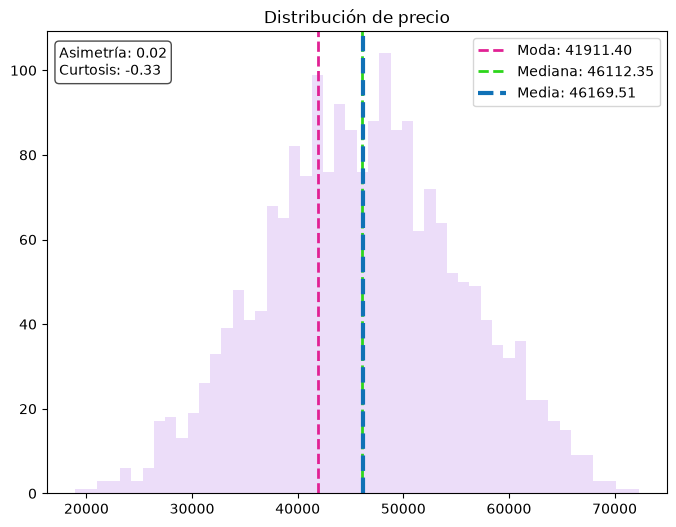

In [120]:
price_histogram, ax = create_histogram(df, 'Price', 'precio')

Analisis de distribucion de precios
- la distribucion asemeja a una distribucion normal
- skewness cercano a cero indica alta simetria (lo cual puede aprecierse en el plot)
- curtosis cercana nuevamente indica que la distribucion se asemeja bastabte a la distribucion normal


### Kilometraje

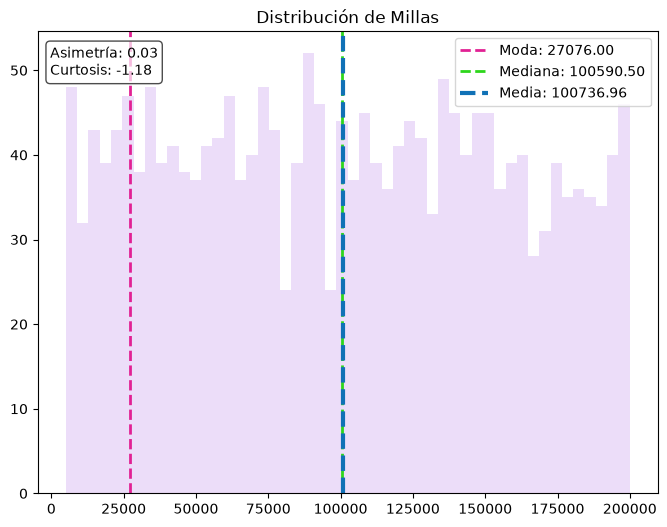

In [121]:
df.head(3)
milage_hist, ax = create_histogram(df, 'Mileage', 'Millas')

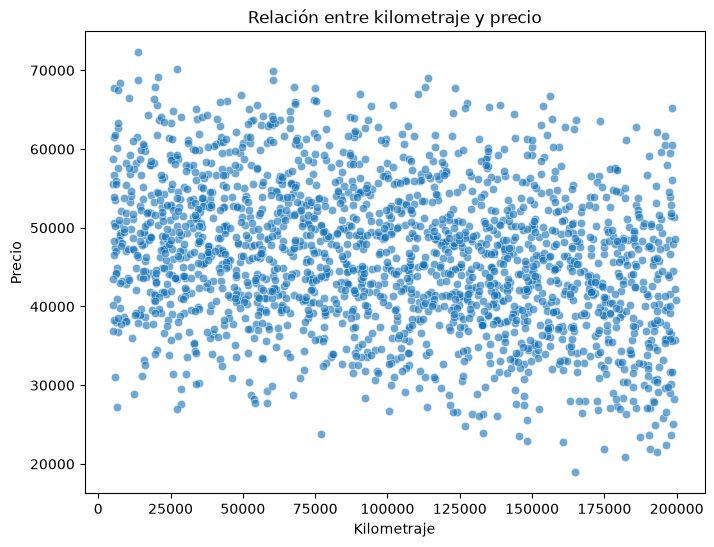

In [122]:
# Analizemos la relacion entre millas y precio
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Mileage', y='Price', alpha=0.6, color="#1071B6")
plt.title('Relación entre kilometraje y precio')
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

In [123]:
df['Brand'].value_counts()

Brand
Toyota     352
Hyundai    337
Tesla      330
Honda      329
BMW        326
Ford       326
Name: count, dtype: int64

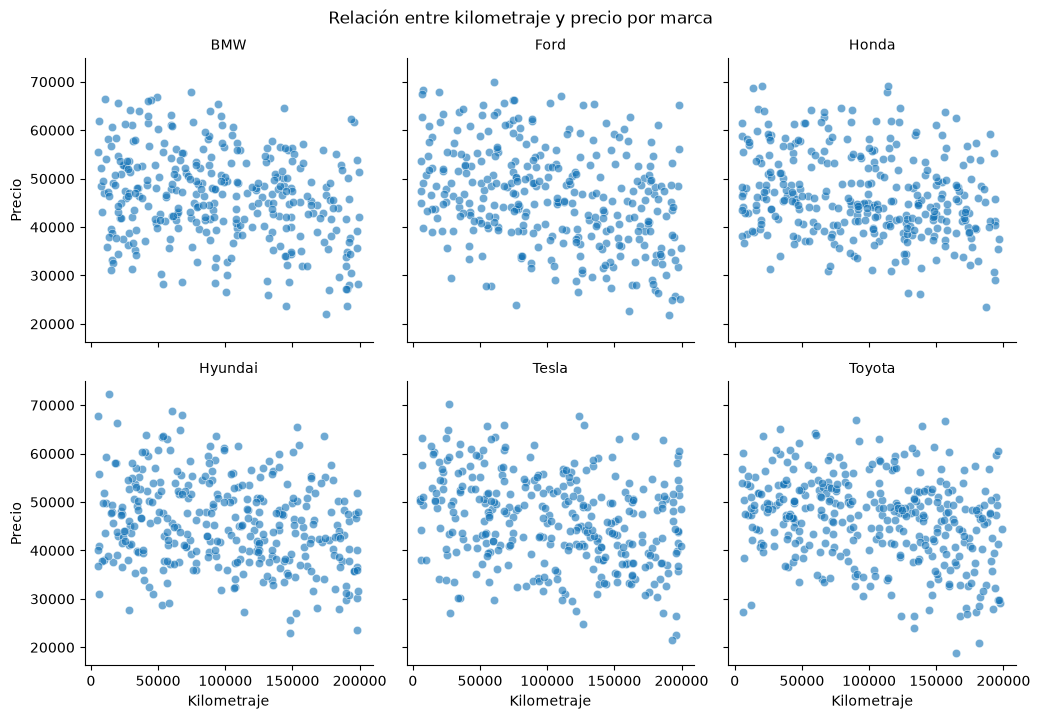

In [124]:
# como el grafico anterior no nos da ninguna pista, probemos la relacion precio-milage agrupados por marca
g = sns.relplot(
    data=df, x='Mileage', y='Price', col='Brand', col_wrap=3,
    alpha=0.6, height=3.5, color="#1071B6",
)
g.set_axis_labels('Kilometraje', 'Precio')
g.set_titles('{col_name}')
g.figure.suptitle('Relación entre kilometraje y precio por marca', y=1.02)
plt.show()

Resultado: no se puede apreciar una clara relacion entre kilometraje y precio como era de esperarse, inclusive cuando se agrupa por marcas.

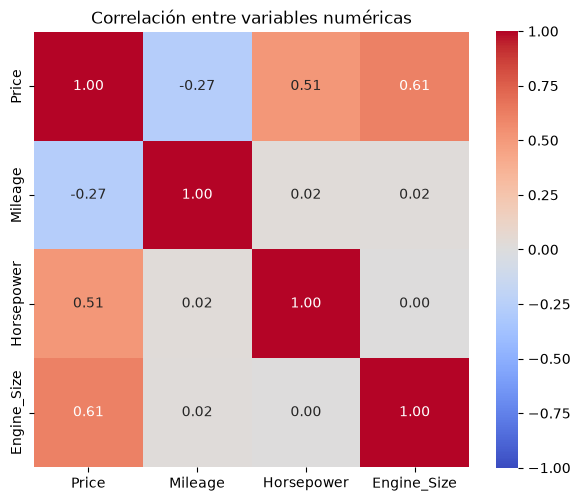

In [125]:
# creamos heatmap de variables numericas price, milage, horsepower, engine_size
numeric_cols = ['Price', 'Mileage', 'Horsepower', 'Engine_Size']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

El heatmap creado nos muestra que no se hayan relaciones fuertes entre las varibles numericas estudiadas.

### Analisis de variables categoricas

In [126]:
# empezamos por analizar la distribucion por modelo
model_year_count = df['Model_Year'].value_counts().rename('Cantidad').to_frame()
model_year_count['Porcentaje'] = (model_year_count['Cantidad'] / len(df) * 100).round(2).astype(str) + '%'
model_year_count

,Cantidad,Porcentaje
Model_Year,,
2008,124,6.2%
2021,118,5.9%
2017,114,5.7%
2012,114,5.7%
2007,113,5.65%
2019,113,5.65%
2023,110,5.5%
2006,110,5.5%
2013,109,5.45%


Podemos apreciar que los modelos estan distribuidos en partes muy parecidas.

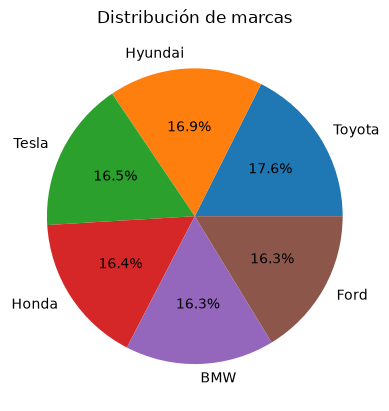

In [127]:
# Analizemos la distribucion por marcas
marcas_count = df.Brand.value_counts().rename('Marca')
plt.pie(marcas_count, labels=marcas_count.index, autopct='%1.1f%%')
plt.title('Distribución de marcas')
plt.show()

podemos observar que las marcas tambien se distribuyen de manera uniforme.

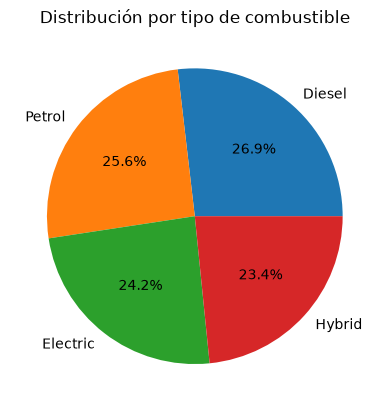

In [128]:
# Analizemos la distribucion por tipo de combustible
fuel_count = df['Fuel_Type'].value_counts().rename('Fuel_type')
plt.pie(fuel_count, labels=fuel_count.index, autopct='%1.1f%%')
plt.title('Distribución por tipo de combustible')
plt.show()

### Valores atipicos

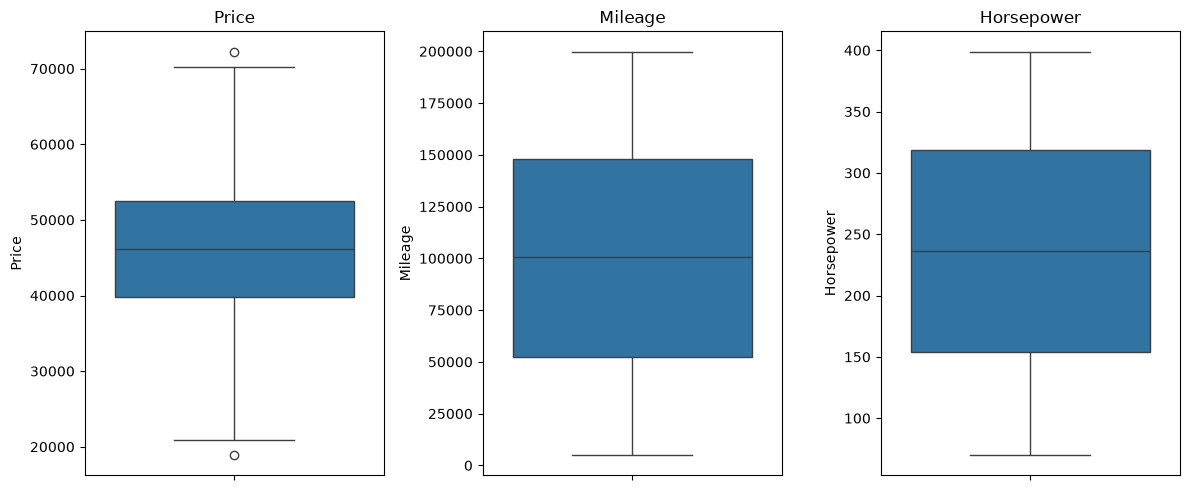

In [129]:
# comparamos los boxplots de precio, kilometraje y potencia en una sola figura
# se usa un subplot por variable ya que sus escalas son muy distintas
variables = ['Price', 'Mileage', 'Horsepower']
fig, axes = plt.subplots(1, len(variables), figsize=(12, 5))

for ax, variable in zip(axes, variables):
    sns.boxplot(y=df[variable], ax=ax)
    ax.set_title(variable)

plt.tight_layout()
plt.show()

Analisis diagramas de caja
- Precio: vemos que la distribucion es muy uniforma y posee unos otliers por encima del bigote superior e inferior, todo esto se condice con lo que mencionamos anteriormente de que tiene una dorma normal
- Kilometraje (Milage) y potencia (Horsepower): en este caso no se ven outliers, como vimos en los histogramas correpondientes a dichas variables, estas poseen una ditribucion uniforme, sin valores extremos.

### Conclusión
- El precio presenta una distribución cercana a la normal, sin una correlación clara con el resto de las variables numéricas (kilometraje, potencia, cilindrada).
- Kilometraje y potencia se distribuyen de manera uniforme, sin outliers.
- Variables categóricas como modelo, marca y tipo de combustible también están distribuidas de forma equitativa entre sus categorías.
- En conjunto, esta uniformidad en todas las variables sugiere que el dataset fue generado sintéticamente y no proviene de datos reales de mercado.